# Bitcoin News Keyword Trend Analysis

This notebook demonstrates how to use TextBlob to analyze Bitcoin news articles, identify trending keywords, and correlate them with Bitcoin price movements. We'll walk through the entire analysis pipeline from data collection to visualization.

## Setup and Environment Preparation

First, let's import the necessary libraries and create the required directories for our analysis.

In [1]:
# Import necessary libraries
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import time
import json
from datetime import datetime

# Import the utility functions
import TextBlob1_Utils as utils

# Create necessary directories if they don't exist
os.makedirs('data', exist_ok=True)
os.makedirs('figures', exist_ok=True)
os.makedirs('figures/html', exist_ok=True)
os.makedirs('dashboard', exist_ok=True)
os.makedirs('dashboard/assets', exist_ok=True)

✅ Successfully imported enhanced Granger causality functions


## Analysis Pipeline Introduction

Our analysis follows these steps:
1. Fetch current Bitcoin price
2. Retrieve Bitcoin-related news articles
3. Get historical Bitcoin price data
4. Extract keywords from news articles
5. Analyze trends and correlations
6. Perform Granger causality tests
7. Generate visualizations
8. Create an interactive dashboard

Let's start by printing a header for our analysis:

In [2]:
# Print header
print("=" * 80)
print("🔎 BITCOIN NEWS KEYWORD TREND ANALYSIS 🔎")
print("=" * 80)
print("Analyzing Bitcoin-related news to identify trending keywords")
print("and correlate their frequency with Bitcoin price movements.")
print("=" * 80)

🔎 BITCOIN NEWS KEYWORD TREND ANALYSIS 🔎
Analyzing Bitcoin-related news to identify trending keywords
and correlate their frequency with Bitcoin price movements.


## Step 1: Fetch Current Bitcoin Price

First, we'll get the current Bitcoin price using the CoinGecko API through our utility function.

In [3]:
# Step 1: Fetch current Bitcoin price
print("\n💰 Fetching current Bitcoin price...")
current_price = utils.fetch_current_bitcoin_price()
if current_price:
    print(f"✅ Current Bitcoin price: ${current_price['price']:,.2f}")
else:
    print("⚠️ Could not get current Bitcoin price. Using historical or sample data.")


💰 Fetching current Bitcoin price...
  → Cached price data expired (5 min), fetching fresh data...
  → Fetching current Bitcoin price...
  ✓ Current Bitcoin price: $103,288.00
✅ Current Bitcoin price: $103,288.00


## Step 2: Fetch Bitcoin News Articles

Next, we'll retrieve Bitcoin-related news articles using the NewsAPI. If the API request fails, we'll create sample data for demonstration purposes.

In [4]:
# Step 2: Fetch news data - use 30 days to stay within free API limits
print("\n📰 Fetching Bitcoin news articles...")
news_data = utils.fetch_bitcoin_news(days=30, query='bitcoin OR cryptocurrency', language='en')

# If news data could not be fetched, use sample data
if news_data is None:
    print("⚠️ No news data retrieved. Using sample data for demonstration...")
    # Create sample data for demonstration
    dates = pd.date_range(start='2023-05-01', periods=5)
    sample_articles = []
    
    for i, date in enumerate(dates):
        sample_articles.append({
            'title': f"Sample Bitcoin Article {i+1}",
            'description': f"This is a sample article about Bitcoin and cryptocurrency for demonstration purposes.",
            'publishedAt': date,
            'source': {'name': 'Sample News'},
            'url': 'https://example.com',
            'urlToImage': '',
            'fetched_date': date.strftime('%Y-%m-%d')
        })
    
    news_data = pd.DataFrame(sample_articles)
    news_data['publishedAt'] = pd.to_datetime(news_data['publishedAt'])
    news_data['date'] = news_data['publishedAt'].dt.date
    news_data['hour'] = news_data['publishedAt'].dt.hour
    
    # Save the sample data
    news_data.to_csv('data/bitcoin_news.csv', index=False)
    print("✅ Sample news data created")
else:
    print(f"✅ Successfully fetched {len(news_data)} news articles")


📰 Fetching Bitcoin news articles...
💬 Using search query: 'bitcoin OR cryptocurrency'
📅 Fetching news for the past 30 days
  → Fetching articles for 2025-05-18...
    ✓ No articles found for 2025-05-18
  → Fetching articles for 2025-05-17...
    ✓ Found 22 articles
  → Fetching articles for 2025-05-16...
    ✓ Found 99 articles
  → Fetching articles for 2025-05-15...
    ✓ Found 100 articles
  → Fetching articles for 2025-05-14...
    ✓ Found 99 articles
  → Fetching articles for 2025-05-13...
    ✓ Found 99 articles
  → Fetching articles for 2025-05-12...
    ✓ Found 98 articles
  → Fetching articles for 2025-05-11...
    ✓ Found 100 articles
  → Fetching articles for 2025-05-10...
    ✓ Found 100 articles
  → Fetching articles for 2025-05-09...
    ✓ Found 100 articles
  → Fetching articles for 2025-05-08...
    ✓ Found 99 articles
  → Fetching articles for 2025-05-07...
    ✓ Found 99 articles
  → Fetching articles for 2025-05-06...
    ✓ Found 100 articles
  → Fetching articles fo

## Step 3: Fetch Historical Bitcoin Price Data

To analyze correlations, we need historical Bitcoin price data. We'll use the CoinGecko API to fetch daily price data for the last 30 days.

In [5]:
# Step 3: Fetch price data
print("\n💰 Fetching Bitcoin price data...")
price_df = utils.fetch_bitcoin_prices(days=30, interval='daily')

if price_df is None:
    print("⚠️ No price data retrieved. Using sample data for demonstration...")
    # Create sample price data that mirrors actual Bitcoin behavior
    dates = pd.date_range(start='2023-05-01', periods=5)
    sample_prices = {
        'timestamp': dates,
        'price': [50000, 51200, 49800, 52300, 53100], 
        'date': [d.date() for d in dates],
        'hour': [0, 0, 0, 0, 0]
    }
    price_df = pd.DataFrame(sample_prices)
    
    # Save the sample data
    price_df.to_csv('data/bitcoin_prices.csv', index=False)
    print("✅ Sample price data created")
else:
    print(f"✅ Successfully fetched {len(price_df)} price data points")


💰 Fetching Bitcoin price data...
  ✓ Using cached price data (from 2025-05-18 03:20:41)
  ✓ Using cached price data (last updated: 2025-05-18 00:00:00)
✅ Successfully fetched 31 price data points


## Step 4: Extract Keywords from News Articles

Now we'll use TextBlob to extract meaningful keywords from the news articles. This will help us identify trending topics in Bitcoin news.

In [6]:
# Step 4: Process data - extract keywords
print("\n🔑 Extracting keywords from news articles...")
news_with_keywords = utils.extract_keywords(min_frequency=1, include_titles=True)

# If keyword extraction failed, add basic keywords
if news_with_keywords is None:
    print("⚠️ Keyword extraction failed. Creating basic keywords...")
    
    # Read the news data again
    if os.path.exists('data/bitcoin_news.csv'):
        news_data = pd.read_csv('data/bitcoin_news.csv')
        # Create more realistic but still synthetic keywords
        news_data['keywords'] = [
            ['bitcoin', 'institutional', 'investors', 'price', 'surge'],
            ['regulation', 'treasury', 'compliance', 'exchanges'],
            ['halving', 'price', 'prediction', 'analysts'],
            ['adoption', 'market', 'global', 'research'],
            ['etf', 'approval', 'volatility', 'trading']
        ]
        
        # Save with basic keywords
        news_data.to_csv('data/bitcoin_news_with_keywords.csv', index=False)
        print("✅ Basic keywords added")


🔑 Extracting keywords from news articles...
📊 Processing 2802 news articles for keyword extraction
  → Processed 100/2802 articles
  → Processed 200/2802 articles
  → Processed 300/2802 articles
  → Processed 400/2802 articles
  → Processed 500/2802 articles
  → Processed 600/2802 articles
  → Processed 700/2802 articles
  → Processed 800/2802 articles
  → Processed 900/2802 articles
  → Processed 1000/2802 articles
  → Processed 1100/2802 articles
  → Processed 1200/2802 articles
  → Processed 1300/2802 articles
  → Processed 1400/2802 articles
  → Processed 1500/2802 articles
  → Processed 1600/2802 articles
  → Processed 1700/2802 articles
  → Processed 1800/2802 articles
  → Processed 1900/2802 articles
  → Processed 2000/2802 articles
  → Processed 2100/2802 articles
  → Processed 2200/2802 articles
  → Processed 2300/2802 articles
  → Processed 2400/2802 articles
  → Processed 2500/2802 articles
  → Processed 2600/2802 articles
  → Processed 2700/2802 articles
  → Processed 2800

## Step 5: Analyze Keyword Trends and Price Correlations

With our keywords extracted, we'll analyze trends and correlations between keyword frequencies and Bitcoin price movements.

In [7]:
# Step 5: Analyze trends
print("\n📊 Analyzing keyword trends and price correlations...")
trend_data = utils.analyze_trends(
    time_window='daily', 
    min_freq=5,      # Minimum keyword frequency for reliable correlation
    min_days=5,      # Require keywords to appear on multiple days for better statistics
    verbose=False    # Suppress detailed correlation warnings
)

if trend_data is None or trend_data.empty:
    print("❌ Trend analysis failed. Cannot proceed with visualization.")


📊 Analyzing keyword trends and price correlations...
✅ Successfully loaded news data with 2802 articles
✅ Successfully loaded price data with 31 data points
  → Filtered to 1478 keywords with at least 5 mentions across 5 days

Keyword stats after filtering:
                total_mentions  unique_days
keyword                                    
bitcoin                   1060           28
crypto                     752           28
market                     395           28
cryptocurrency             392           28
trump                      373           28
btc                        373           28
price                      371           28
bull                       213           28
xrp                        166           28
etf                        157           27
u.s.                       153           28
investors                  152           28
new                        149           28
exchange                   145           26
donald                     135       

## Step 6: Granger Causality Tests

If our trend analysis was successful, we'll run Granger causality tests to determine if keyword frequencies might have predictive power for Bitcoin price movements.


🧪 Running Granger causality tests...
📊 Found 1478 unique keywords for causality testing
📊 Sufficient data available for basic causality tests
📊 Found 1478 unique keywords
📊 Top keywords by frequency: analyst, cryptocurrency, key, surge, strategy, platform, ethereum, bitcoin, crypto, eth
📊 Price series for 'analyst' is not stationary (p=0.4091), applying transformation
📊 Testing if 'analyst' Granger-causes price changes...
📊 Testing if price changes Granger-cause 'analyst'...
✅ Tested 'analyst': K→P p-value=0.4365, P→K p-value=0.1419
📊 Price series for 'cryptocurrency' is not stationary (p=0.4091), applying transformation
📊 Testing if 'cryptocurrency' Granger-causes price changes...
📊 Testing if price changes Granger-cause 'cryptocurrency'...
✅ Tested 'cryptocurrency': K→P p-value=0.5792, P→K p-value=0.4278
📊 'key' frequency is not stationary (p=0.2582), applying transformation
📊 Price series for 'key' is not stationary (p=0.4091), applying transformation
📊 Testing if 'key' Granger-cau

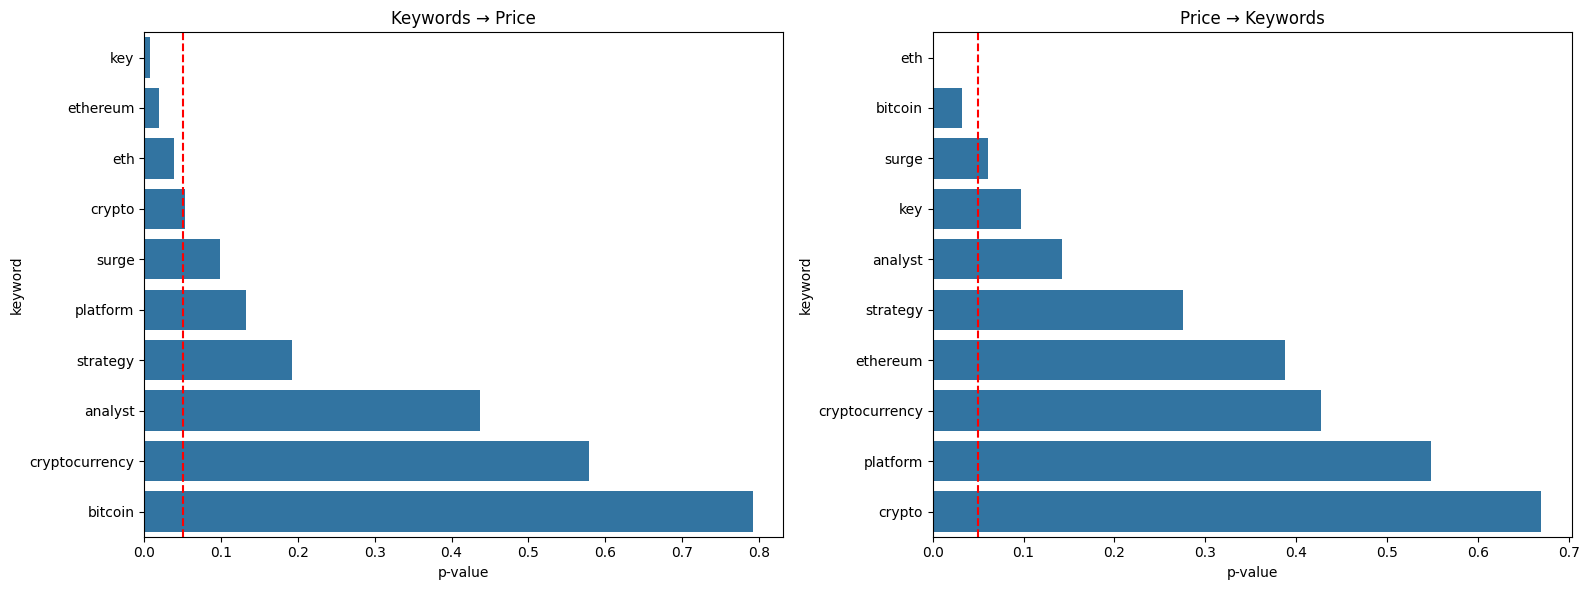

In [8]:
if trend_data is not None and not trend_data.empty:
    # Small delay to make sure files are written
    time.sleep(1)
    
    # Step 6: Run Granger causality tests
    print("\n🧪 Running Granger causality tests...")
    
    # Check if we have enough data for meaningful Granger tests
    keyword_counts = trend_data.groupby('keyword').size()
    print(f"📊 Found {len(keyword_counts)} unique keywords for causality testing")
    
    # For daily data, we need at least 20 data points for reliable causality testing
    # But use what we have with appropriate limitations
    if len(price_df) >= 25:
        print("📊 Sufficient data available for basic causality tests")
        causality_results = utils.run_granger_tests(top_n=10, max_lag=3, min_data_points=15)
    elif len(price_df) >= 15:
        print("📊 Limited data available - using reduced test parameters")
        causality_results = utils.run_granger_tests(top_n=8, max_lag=2, min_data_points=10)
    else:
        print("⚠️ Very limited data for causality testing. Using minimal parameters.")
        print("⚠️ Results should be considered preliminary and may not be statistically reliable.")
        causality_results = utils.run_granger_tests(top_n=5, max_lag=1, min_data_points=5)

## Step 7: Generate Visualizations

Now we'll create visualizations to better understand the relationships between keywords and Bitcoin price.

In [9]:
# Step 7: Generate visualizations
print("\n📊 Generating visualizations...")

# Get top keywords
if 'keyword' in trend_data.columns:
    # Prioritize significant keywords from Granger tests if available
    significant_keywords = []
    if causality_results is not None and 'k2p_significant' in causality_results.columns:
        significant_keywords = causality_results[causality_results['k2p_significant']]['keyword'].tolist()
        if significant_keywords:
            print(f"📊 Found {len(significant_keywords)} statistically significant keywords: {', '.join(significant_keywords)}")
    
    # Use top frequent keywords for visualization but prefer crypto-related keywords
    crypto_related = ['bitcoin', 'btc', 'crypto', 'cryptocurrency', 'blockchain', 
                     'ethereum', 'eth', 'defi', 'nft', 'mining', 'halving']
    
    # Get crypto-related keywords from the top
    trend_data_sorted = trend_data.sort_values('frequency', ascending=False)
    crypto_keywords = [k for k in trend_data_sorted['keyword'].tolist() 
                      if any(term in k.lower() for term in crypto_related)][:5]
    
    # Get top correlation keywords (both positive and negative)
    # Filter out keywords with too few data points for reliability
    # Check if 'days' column exists
    if 'days' in trend_data.columns:
        reliable_trends = trend_data[trend_data['days'] >= 7]
        if len(reliable_trends) >= 10:
            correlation_keywords = (
                reliable_trends.nlargest(5, 'correlation')['keyword'].tolist() + 
                reliable_trends.nsmallest(5, 'correlation')['keyword'].tolist()
            )
        else:
            correlation_keywords = (
                trend_data.nlargest(5, 'correlation')['keyword'].tolist() + 
                trend_data.nsmallest(5, 'correlation')['keyword'].tolist()
            )
    else:
        # If 'days' column is missing, use the full trend_data
        print("⚠️ 'days' column not found in trend data. Using all available keywords.")
        correlation_keywords = (
            trend_data.nlargest(5, 'correlation')['keyword'].tolist() + 
            trend_data.nsmallest(5, 'correlation')['keyword'].tolist()
        )


📊 Generating visualizations...
📊 Found 3 statistically significant keywords: key, ethereum, eth


### Create Individual Keyword Charts

Let's visualize the relationship between individual keyword frequencies and Bitcoin price over time.

In [10]:
if trend_data is not None and not trend_data.empty and 'top_keywords' in locals():
    # Create individual keyword charts
    for keyword in top_keywords[:3]:  # Just show first 3 for example
        print(f"\n📈 Creating visualization for keyword '{keyword}'...")
        utils.plot_keyword_vs_price(
            keyword,
            save_fig=True,
            display_fig=True
        )
        # Allow time between visualizations
        time.sleep(1)

## Step 8: Generate Interactive Dashboard

Finally, we'll create an interactive dashboard that presents our findings in a user-friendly format.

In [11]:
if trend_data is not None and not trend_data.empty and 'top_keywords' in locals():
    # Step 8: Generate dashboard
    print("\n📊 Generating interactive dashboard...")
    from main import generate_dashboard
    dashboard_path = generate_dashboard(top_keywords, trend_data, causality_results, current_price)

## Results Summary

Here's a summary of our analysis results:

In [12]:
if trend_data is not None and not trend_data.empty:
    # Final message
    print("\n✅ Analysis complete!")
    print("\n📊 RESULTS SUMMARY 📊")
    print("=" * 40)
    print(f"📰 Analyzed {len(news_data)} news articles")
    print(f"💰 Used daily price data for time series analysis")
    print(f"🔑 Extracted {len(trend_data)} unique keywords")
    if 'top_keywords' in locals():
        print(f"📈 Top keywords: {', '.join(top_keywords[:5])}")
    
    # Show where to find results
    print("\n📁 OUTPUT FILES 📁")
    print("=" * 40)
    print("📊 Data files saved in: ./data/")
    print("📈 Visualizations saved in: ./figures/")
    
    if 'dashboard_path' in locals() and dashboard_path:
        print(f"🌐 Interactive dashboard: {dashboard_path}")
        
        # Try to open the dashboard in a browser
        try:
            import webbrowser
            webbrowser.open(f'file:///{os.path.abspath(dashboard_path)}')
            print("\n🌐 Dashboard opened in your browser")
        except:
            print(f"\n🌐 Dashboard is available at: {os.path.abspath(dashboard_path)}")


✅ Analysis complete!

📊 RESULTS SUMMARY 📊
📰 Analyzed 2800 news articles
💰 Used daily price data for time series analysis
🔑 Extracted 1478 unique keywords

📁 OUTPUT FILES 📁
📊 Data files saved in: ./data/
📈 Visualizations saved in: ./figures/


## Running the Complete Analysis Pipeline

Let's run the full `main.py` script to generate the dashboard:

Running Bitcoin news keyword analysis...

🔎 BITCOIN NEWS KEYWORD TREND ANALYSIS 🔎
Analyzing Bitcoin-related news to identify trending keywords
and correlate their frequency with Bitcoin price movements.


🐳 Running inside Docker container

💰 Fetching current Bitcoin price...
  ✓ Using cached price data (from 2025-05-18 03:20:41)
✅ Current Bitcoin price: $103,288.00

📰 Fetching Bitcoin news articles...
💬 Using search query: 'bitcoin OR cryptocurrency'
📅 Fetching news for the past 30 days
  → Fetching articles for 2025-05-18...
    ✓ No articles found for 2025-05-18
  → Fetching articles for 2025-05-17...
    ✓ Found 22 articles
  → Fetching articles for 2025-05-16...
    ✓ Found 99 articles
  → Fetching articles for 2025-05-15...
    ✓ Found 100 articles
  → Fetching articles for 2025-05-14...
    ✓ Found 99 articles
  → Fetching articles for 2025-05-13...
    ✓ Found 99 articles
  → Fetching articles for 2025-05-12...
    ✓ Found 98 articles
  → Fetching articles for 2025-05-11...
    


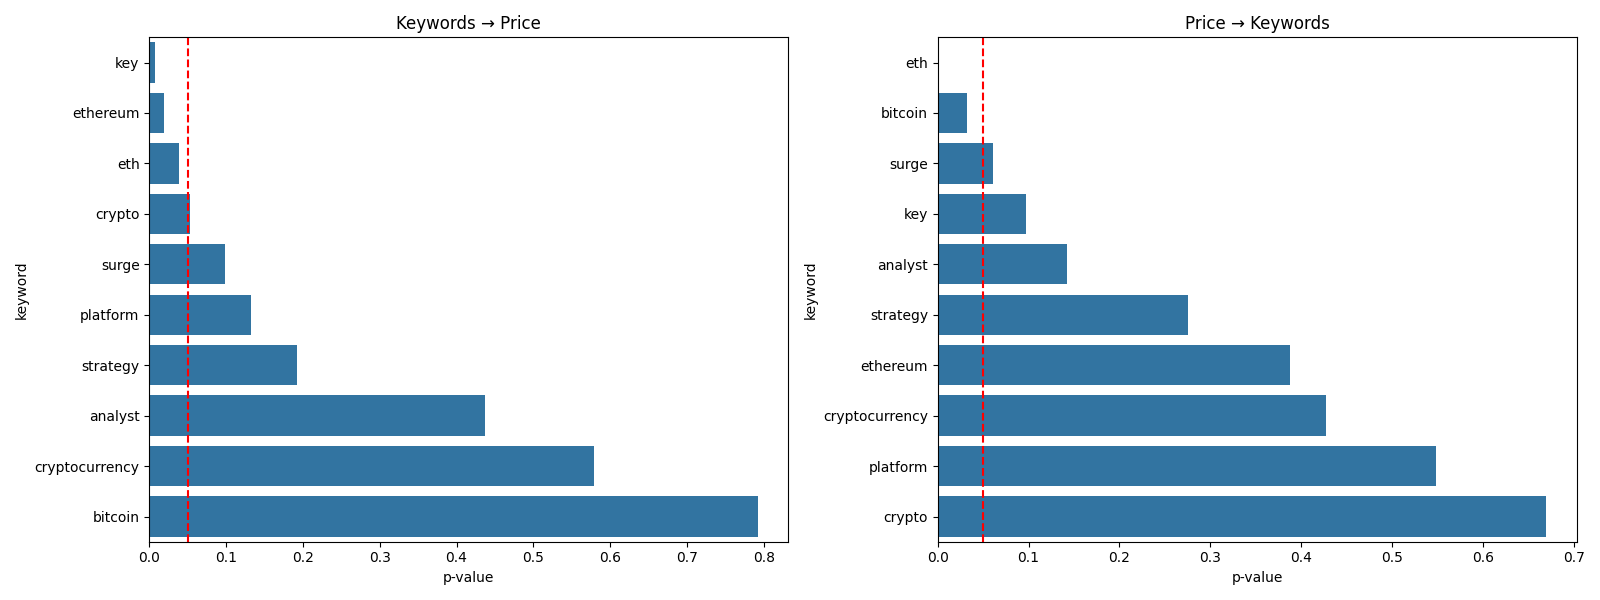

✅ Dashboard displayed successfully!


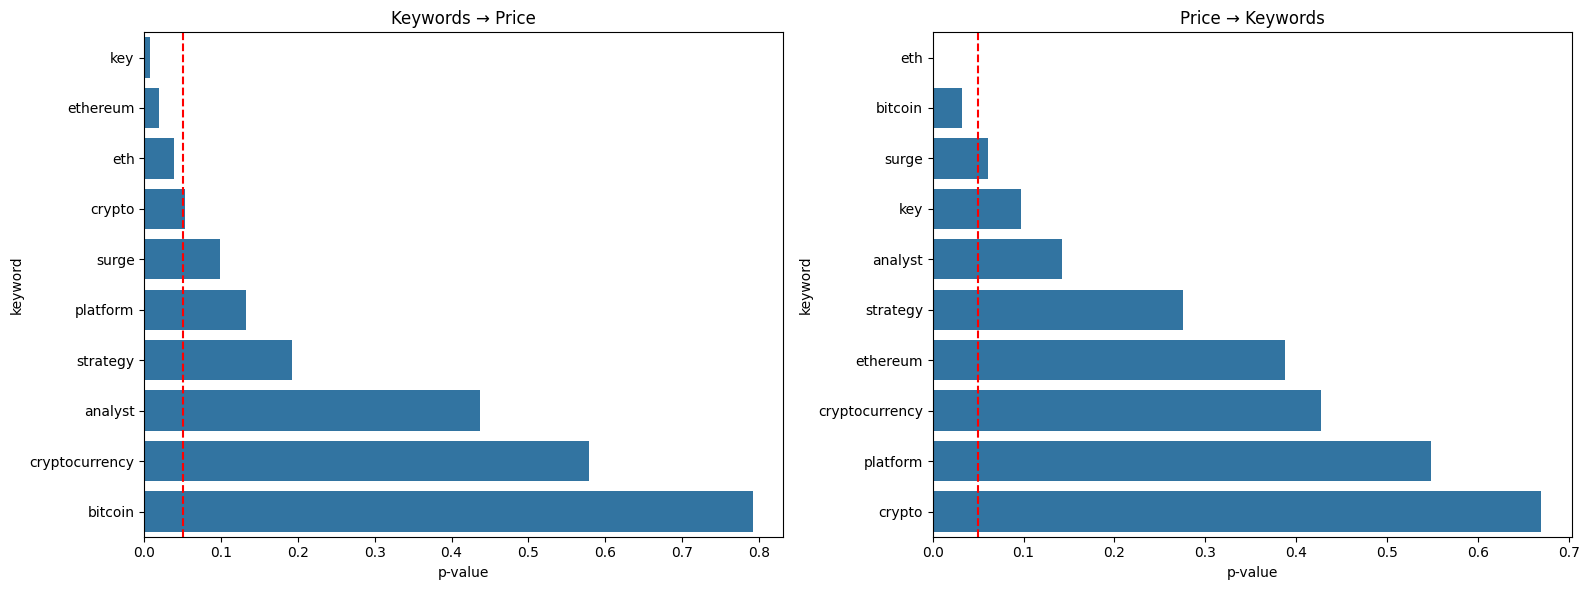

In [13]:
# Complete code to generate and display the dashboard in Jupyter notebook

# Step 1: Run the main analysis to generate the dashboard
import main
import os
import base64
import re
import time
from IPython.display import HTML, display

# Run the main analysis
print("Running Bitcoin news keyword analysis...")
main.main()
print("Analysis complete!")

# Wait a moment to ensure all files are written
time.sleep(2)

# Step 2: Read and display the dashboard
dashboard_path = 'dashboard/keyword_trends.html'

if not os.path.exists(dashboard_path):
    display(HTML('<div style="color:red; font-weight:bold">Dashboard not found. Check for errors above.</div>'))
else:
    # Function to convert images to base64
    def get_base64_image(img_path):
        try:
            with open(img_path, 'rb') as img_file:
                return base64.b64encode(img_file.read()).decode('utf-8')
        except Exception as e:
            print(f"Warning: Could not embed image {img_path}: {e}")
            return ""
    
    # Read the dashboard HTML
    with open(dashboard_path, 'r', encoding='utf-8') as f:
        dashboard_html = f.read()
    
    # Find and replace all image references with base64 data
    img_pattern = re.compile(r'src="([^"]+\.png)"')
    img_matches = img_pattern.findall(dashboard_html)
    
    for img_path in img_matches:
        # Convert relative path to absolute
        if img_path.startswith('../figures/'):
            abs_img_path = img_path.replace('../figures/', 'figures/')
        else:
            abs_img_path = img_path
        
        if os.path.exists(abs_img_path):
            # Get base64 data
            base64_data = get_base64_image(abs_img_path)
            if base64_data:
                data_url = f"data:image/png;base64,{base64_data}"
                dashboard_html = dashboard_html.replace(f'src="{img_path}"', f'src="{data_url}"')
        else:
            print(f"Warning: Image not found: {abs_img_path}")
    
    # Handle HTML iframes in the dashboard
    iframe_pattern = re.compile(r'<iframe src="([^"]+)"')
    iframe_matches = iframe_pattern.findall(dashboard_html)
    
    for iframe_src in iframe_matches:
        if iframe_src.startswith('../figures/html/'):
            html_file = iframe_src.replace('../figures/html/', 'figures/html/')
            if os.path.exists(html_file):
                # Replace with message about interactive content
                placeholder = (
                    '<div style="text-align:center; padding:15px; background:#f8f9fa; '
                    'border:1px solid #ddd; border-radius:5px;">'
                    '<p style="font-weight:bold;">Interactive Plot Preview</p>'
                    '<p>Interactive visualizations are available in the full dashboard</p>'
                    '</div>'
                )
                dashboard_html = dashboard_html.replace(
                    f'<iframe src="{iframe_src}" frameborder="0"></iframe>', 
                    placeholder
                )
    
    # Display the dashboard in the notebook
    display(HTML(dashboard_html))
    
    # Also display a link to open the full dashboard
    dashboard_abs_path = os.path.abspath(dashboard_path).replace('\\', '/')
    dashboard_uri = f"file:///{dashboard_abs_path}"
    
    display(HTML(f'''
        <div style="margin-top:20px; text-align:center;">
            <a href="{dashboard_uri}" target="_blank" 
               style="display:inline-block; padding:10px 20px; background:#4CAF50; 
                     color:white; text-decoration:none; border-radius:5px; font-weight:bold;">
                Open Full Dashboard in New Tab
            </a>
        </div>
    '''))
    
    print(f"✅ Dashboard displayed successfully!")

## Conclusion

In this notebook, we've demonstrated a complete pipeline for analyzing Bitcoin news articles using TextBlob. We:

1. Collected and processed Bitcoin news articles
2. Extracted meaningful keywords using TextBlob
3. Analyzed the relationship between keyword trends and Bitcoin price
4. Performed Granger causality tests to identify potential predictive relationships
5. Created visualizations and an interactive dashboard

This analysis provides insights into how news coverage and specific topics might relate to Bitcoin price movements.

### Next Steps

For further analysis, you might consider:
- Incorporating sentiment analysis of news articles
- Extending the time period for more robust statistical analysis
- Including more cryptocurrency price data for comparative analysis
- Creating predictive models based on keyword trends